# quoFEM Sensitivity Analysis Example using DAPI

Pedro Arduino - UW Computational Geomechanics Group

Aakash B. Satish & Sangri Yi - SimCenter, UC Berkeley

This example shows how to run a quoFEM global sensitivity analysis on DesignSafe from a Jupyter notebook using the DesignSafe API ([dapi](https://github.com/DesignSafe-CI/dapi)), and how to postprocess the results in Python.

The workflow submits the SimCenter UQ application (`simcenter-uq-stampede3`) to TACC Stampede3. dapi recognizes SimCenter apps and applies their interface contract automatically: `ds.jobs.prepare_inputs` points the workflow JSON (`scInput.json`) at the SimCenter backend installation and bundles the inputs into a single `tmpSimCenter.zip` (staging one file instead of many avoids the Tapis transfers service's per-file overhead), `ds.jobs.generate` wires the input directory and the `inputFile`/`driverFile` environment variables the app expects, and `job.get_results()` retrieves and parses the UQ outputs.

The analysis performs Monte Carlo sampling (500 samples) of three PM4Sand constitutive model parameters (`Dr`, `G0`, `hpo`) in a cyclic direct simple shear simulation and reports the sensitivity of the number-of-cycles engineering demand parameters (EDPs).

**Note: This example takes roughly 30-45 minutes end-to-end on Stampede3 (`skx-dev` queue), much of it queue time.**

**Note: Executing this notebook requires a TACC allocation, set in `tacc_allocation`. Please contact DesignSafe/TACC to obtain an allocation.**

# Setup DAPI and start quoFEM job

In [6]:
%pip install --upgrade --quiet git+https://github.com/DesignSafe-CI/dapi.git


[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [7]:
%matplotlib inline

In [9]:
# Import DAPI and other required libraries
from dapi import DSClient
import os
import json

import dapi

print(f"dapi version: {dapi.__version__}")

dapi version: 0.5.3


In [10]:
try:
    ds = DSClient()
except Exception as e:
    print(f"Authentication failed: {e}")
    raise SystemExit("Stopping notebook due to authentication failure.")

Authentication successful.
DatabaseAccessor initialized. Connections will be created on first access.
TMS credentials ready: frontera, stampede3, ls6


### Setup job description

In [11]:
# Job configuration parameters
job_name: str = "quofem-sensitivity-dapi"
app_id: str = "simcenter-uq-stampede3"
tacc_allocation: str = "DS-Portal-SPARC2026"  # MUST USE YOUR OWN ALLOCATION !!
archive_system: str = "designsafe"  # archive to MyData (default path)
archive_path = None

# To archive into a shared DesignSafe project instead (so collaborators can see
# the job and its outputs), point archive_system at the project system id:
# archive_system = "project-8332570396718076396-242ac118-0001-012"
# archive_path = f"quoFEM_jobs/{job_name}"

queue: str = "skx-dev"
node_count: int = 1
cores_per_node: int = 48
memory_mb: int = 128000
max_job_minutes: int = 120

In [12]:
ds_path = os.getcwd() + "/DS_input"
print(f"DesignSafe path: {ds_path}")

DesignSafe path: /home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input
Translated '/home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input' to 'tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input' using t.username
Input URI: tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input


### Prepare the SimCenter inputs

The quoFEM desktop application writes local paths into `scInput.json`. `ds.jobs.prepare_inputs` rewrites them to the SimCenter backend installation registered for this app (pass `backend_dir=...` to override), reports the UQ workflow (engine, random variables, EDPs), and bundles the inputs into a single `tmpSimCenter.zip` in a staging directory — the app unpacks it natively on the execution system, and staging one file instead of many is dramatically faster (the Tapis transfers service pays a per-file scheduling cost of up to ~40s under load). Pass `bundle=False` to stage the loose directory instead.

In [13]:
info = ds.jobs.prepare_inputs(app_id, ds_path)

rv_names = info["random_variables"]
edp_names = info["edps"]

# Stage the bundled directory (contains only tmpSimCenter.zip)
input_uri = ds.files.to_uri(info["staged_dir"])
print(f"Input URI: {input_uri}")

Preparing inputs with 'simcenter' app profile.
Updated remoteAppDir in /home/jupyter/MyData/template-notebooks/quoFEM-sensitivity/DS_input/tmp.SimCenter/templatedir/scInput.json
UQ engine: SimCenterUQ (Sensitivity Analysis)
Random variables: ['Dr', 'G0', 'hpo']
EDPs: ['nCycles010_1', 'nCycles010_2', 'nCycles013', 'nCycles015', 'nCycles017', 'nCycles020']


### Generate job request

In [14]:
# Generate job request dictionary using app defaults. dapi applies the
# SimCenter app profile automatically: the input directory is exposed to the
# app as $inputDirectory, and the inputFile/driverFile environment variables
# are set to scInput.json and driver.
job_dict = ds.jobs.generate(
    app_id=app_id,
    input_dir_uri=input_uri,
    archive_system=archive_system,
    archive_path=archive_path,
    max_minutes=max_job_minutes,
    allocation=tacc_allocation,
    queue=queue,
    job_name=job_name,
    node_count=node_count,
    cores_per_node=cores_per_node,
    memory_mb=memory_mb,
)

print("Generated job request:")
print(json.dumps(job_dict, indent=2, default=str))

Generating job request for app 'simcenter-uq-stampede3'...
Using App Details: simcenter-uq-stampede3 v2.0.0
script_filename is None, skipping script parameter placement.
Adding/Updating TACC allocation: DS-Portal-SPARC2026
Applying 'simcenter' app profile adjustments.
Job request dictionary generated successfully.
Generated job request:
{
  "name": "quofem-sensitivity-dapi",
  "appId": "simcenter-uq-stampede3",
  "appVersion": "2.0.0",
  "description": "simcenter-uq on Stampede3",
  "execSystemId": "stampede3",
  "archiveSystemId": "designsafe.storage.default",
  "archiveSystemDir": "${EffectiveUserId}/tapis-jobs-archive/${JobCreateDate}/${JobUUID}",
  "archiveOnAppError": true,
  "execSystemLogicalQueue": "skx-dev",
  "nodeCount": 1,
  "coresPerNode": 48,
  "maxMinutes": 120,
  "memoryMB": 128000,
  "isMpi": false,
  "tags": [],
  "fileInputs": [
    {
      "name": "Input Directory",
      "sourceUrl": "tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS

### Run job

In [15]:
# Submit job using dapi
submitted_job = ds.jobs.submit(job_dict)
print(f"Job launched with UUID: {submitted_job.uuid}")
print(
    "Can also check in DesignSafe portal under - Workspace > Tools & Application > Job Status"
)


--- Submitting Tapis Job Request ---
{
  "name": "quofem-sensitivity-dapi",
  "appId": "simcenter-uq-stampede3",
  "appVersion": "2.0.0",
  "description": "simcenter-uq on Stampede3",
  "execSystemId": "stampede3",
  "archiveSystemId": "designsafe.storage.default",
  "archiveSystemDir": "${EffectiveUserId}/tapis-jobs-archive/${JobCreateDate}/${JobUUID}",
  "archiveOnAppError": true,
  "execSystemLogicalQueue": "skx-dev",
  "nodeCount": 1,
  "coresPerNode": 48,
  "maxMinutes": 120,
  "memoryMB": 128000,
  "isMpi": false,
  "tags": [],
  "fileInputs": [
    {
      "name": "Input Directory",
      "sourceUrl": "tapis://designsafe.storage.default/kks32/template-notebooks/quoFEM-sensitivity/DS_input",
      "autoMountLocal": true,
      "envKey": "inputDirectory",
      "targetPath": "*"
    }
  ],
  "parameterSet": {
    "schedulerOptions": [
      {
        "name": "TACC Allocation",
        "arg": "-A DS-Portal-SPARC2026"
      }
    ],
    "envVariables": [
      {
        "key": "inp

In [16]:
# Monitor job status using dapi
final_status = submitted_job.monitor(interval=30)
print(f"Job finished with status: {final_status}")

# Interpret job status
ds.jobs.interpret_status(final_status, submitted_job.uuid)

# Display runtime summary
submitted_job.print_runtime_summary(verbose=False)


Monitoring Job: e67add9e-70d7-4d73-b34d-2e987aa658e8-007


Waiting for job to start: 0 checks [00:00, ? checks/s]

Monitoring job:   0%|          | 0/240 [00:00<?, ? checks/s]

	Status: RUNNING
	Status: ARCHIVING
	Status: FINISHED
Job finished with status: FINISHED
Job e67add9e-70d7-4d73-b34d-2e987aa658e8-007 completed successfully.

Runtime Summary
---------------
QUEUED  time: 00:00:12
RUNNING time: 00:16:22
TOTAL   time: 00:29:09
---------------


In [17]:
# Print out last message from the job
print(submitted_job.last_message)

Setting job status to FINISHED.


# Postprocess Results

### Identify job and archived location

In [18]:
# Get archive information using dapi
archive_uri = submitted_job.archive_uri
print(f"Archive URI: {archive_uri}")

# List archive contents
archive_files = ds.files.list(archive_uri)
print("\nArchive contents:")
for item in archive_files:
    print(f"- {item.name} ({item.type})")

Archive URI: tapis://designsafe.storage.default/kks32/tapis-jobs-archive/2026-08-07Z/e67add9e-70d7-4d73-b34d-2e987aa658e8-007
Listing files in system 'designsafe.storage.default' at path 'kks32/tapis-jobs-archive/2026-08-07Z/e67add9e-70d7-4d73-b34d-2e987aa658e8-007'...
Found 11 items.

Archive contents:
- app.json (file)
- app.zip (file)
- DS_input (dir)
- results.zip (file)
- submit.json (file)
- tapisjob.env (file)
- tapisjob.out (file)
- tapisjob.sh (file)
- tapisjob_app.sh (file)
- templatedir.zip (file)
- workdir.tar.gz (file)


### Retrieve the UQ results

`job.get_results()` downloads `results.zip` from the job archive in memory and parses it: the `dakotaTab.out` sample table becomes a DataFrame (`results.samples`) and the Sobol sensitivity indices from `dakota.out` become `results.sobol_indices`.

In [19]:
results = submitted_job.get_results()

samples = results.samples
samples.head()

Fetching 'results.zip' from system 'designsafe.storage.default' path 'kks32/tapis-jobs-archive/2026-08-07Z/e67add9e-70d7-4d73-b34d-2e987aa658e8-007/results.zip'...
Parsed 500 samples from dakotaTab.out.
Parsed Sobol indices for 6 outputs.


,idx,Dr,G0,hpo,nCycles010_1,nCycles010_2,nCycles013,nCycles015,nCycles017,nCycles020
0,1,0.208492,984.40269,2.750463,12.25,12.25,4.50,2.50,1.50,0.50
1,2,0.186365,796.35018,2.275522,8.50,8.50,3.50,1.50,1.25,0.50
2,3,0.429658,749.44646,0.558715,20.25,20.25,9.50,6.25,4.25,3.25
3,4,0.408158,1439.90920,1.427896,41.25,41.25,19.50,12.50,8.50,6.25
4,5,0.341304,379.37589,2.486818,30.25,30.25,12.25,6.50,3.50,2.25


### Monte Carlo samples of the random variables

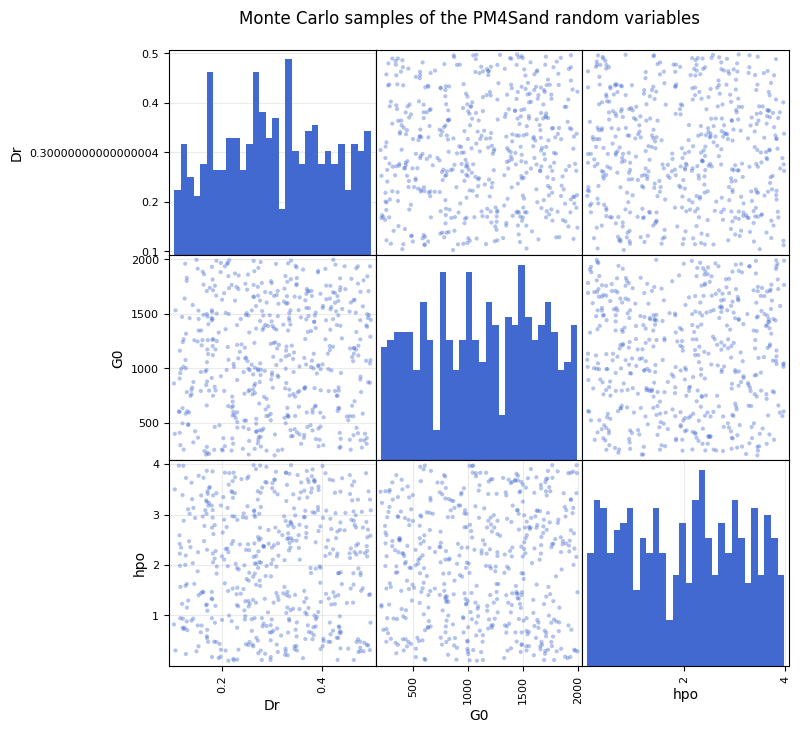

In [20]:
import matplotlib.pyplot as plt
from pandas.plotting import scatter_matrix

axes = scatter_matrix(
    samples[rv_names],
    figsize=(8, 8),
    diagonal="hist",
    color="#4269d0",
    alpha=0.4,
    hist_kwds={"color": "#4269d0", "bins": 30},
)
for ax in axes.ravel():
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
plt.suptitle("Monte Carlo samples of the PM4Sand random variables", y=0.93)
plt.show()

### Distributions of the engineering demand parameters

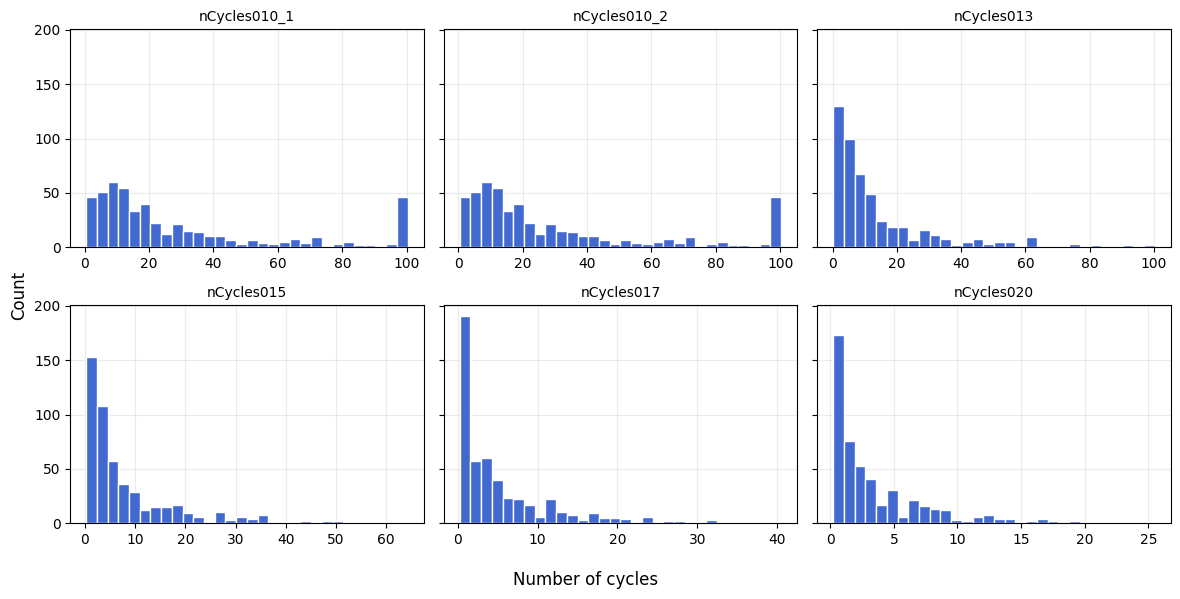

In [21]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)
for ax, edp in zip(axes.ravel(), edp_names):
    ax.hist(samples[edp], bins=30, color="#4269d0", edgecolor="white")
    ax.set_title(edp, fontsize=10)
    ax.grid(alpha=0.25)
    ax.set_axisbelow(True)
fig.supxlabel("Number of cycles")
fig.supylabel("Count")
fig.tight_layout()
plt.show()

### Sobol sensitivity indices

Main indices (`Sm`) measure each variable's direct contribution to the variance of an EDP; total indices (`St`) include interaction effects.

In [22]:
results.sobol_indices

,Sm(Dr),Sm(G0),Sm(hpo),St(Dr),St(G0),St(hpo)
output,,,,,,
nCycles010_1,0.705252,0.020774,0.202146,0.743489,0.020774,0.206538
nCycles010_2,0.705252,0.020774,0.202146,0.743489,0.020774,0.206538
nCycles013,0.738739,0.049170,0.152281,0.774986,0.049170,0.152281
nCycles015,0.703519,0.074396,0.129923,0.786373,0.074396,0.129923
nCycles017,0.725052,0.089140,0.115124,0.725052,0.089140,0.115124
nCycles020,0.724719,0.134530,0.089463,0.767262,0.134530,0.089463


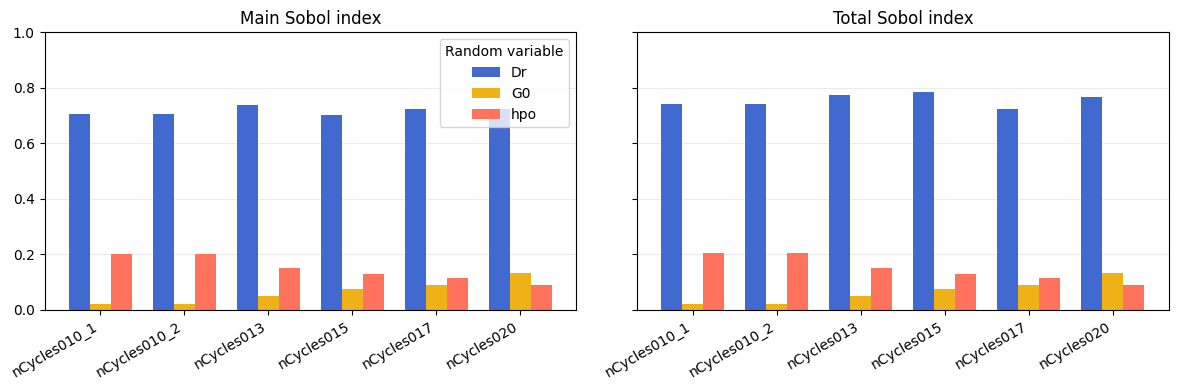

In [23]:
import numpy as np

sobol = results.sobol_indices
palette = ["#4269d0", "#efb118", "#ff725c"]  # fixed hue per random variable

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
x = np.arange(len(sobol.index))
width = 0.25
for ax, prefix, title in zip(axes, ("Sm", "St"), ("Main", "Total")):
    for i, (rv, color) in enumerate(zip(rv_names, palette)):
        ax.bar(
            x + (i - 1) * width,
            sobol[f"{prefix}({rv})"],
            width,
            color=color,
            label=rv if prefix == "Sm" else None,
        )
    ax.set_title(f"{title} Sobol index")
    ax.set_ylim(0, 1)
    ax.set_xticks(x)
    ax.set_xticklabels(sobol.index, rotation=30, ha="right")
    ax.grid(alpha=0.25, axis="y")
    ax.set_axisbelow(True)
axes[0].legend(title="Random variable")
fig.tight_layout()
plt.show()